In [1]:
import pandas as pd

In [3]:
df = pd.read_csv('loan_Application.csv')
df.head()

,Customer_ID,Age,Income,Loan_Amount,Credit_Score,Loan_Term (months),Default_Status (Yes/No)
0,100000,59,48054,23066,608,60,Yes
1,100001,49,196469,37746,665,48,No
2,100002,35,33233,7460,820,48,No
3,100003,63,176140,42297,758,12,Yes
4,100004,28,85727,39743,669,60,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Customer_ID              5000 non-null   int64 
 1   Age                      5000 non-null   int64 
 2   Income                   5000 non-null   int64 
 3   Loan_Amount              5000 non-null   int64 
 4   Credit_Score             5000 non-null   int64 
 5   Loan_Term (months)       5000 non-null   int64 
 6   Default_Status (Yes/No)  5000 non-null   object
dtypes: int64(6), object(1)
memory usage: 273.6+ KB


## Central Tendency & Dispersion

In [5]:
#mean
mean_income = df['Income'].mean()
mean_income

np.float64(109920.0894)

In [6]:
#median
median_income = df['Income'].median()
median_income

109829.5

In [7]:
#mode
mode_income = df['Income'].mode()[0]
mode_income

np.int64(24042)

In [8]:
#Range
loan_range = df['Loan_Amount'].max() - df['Loan_Amount'].min()
loan_range

44984

In [9]:
#Variance
loan_variance = df['Loan_Amount'].var()
loan_variance

166558175.31281337

In [11]:
#Standard Deviation
loan_std = df['Loan_Amount'].std()
loan_std

12905.741951271666

In [12]:
print("Mean Income:", mean_income)
print("Median Income:", median_income)
print("Mode Income:", mode_income)

print("Loan Range:", loan_range)
print("Loan Variance:", loan_variance)
print("Loan Standard Deviation:", loan_std)

Mean Income: 109920.0894
Median Income: 109829.5
Mode Income: 24042
Loan Range: 44984
Loan Variance: 166558175.31281337
Loan Standard Deviation: 12905.741951271666


## Probability & Events

In [15]:
#Probability of Loan Default

default_count = (df['Default_Status (Yes/No)'] == 'Yes').sum()
total = len(df)

prob_default = default_count / total
prob_default

np.float64(0.1872)

In [16]:
#Categorize Credit Score into Ranges

bins = [300, 500, 650, 750, 850]
labels = ['Poor', 'Average', 'Good', 'Excellent']

df['Credit_Category'] = pd.cut(df['Credit_Score'], bins=bins, labels=labels)
df.head()

,Customer_ID,Age,Income,Loan_Amount,Credit_Score,Loan_Term (months),Default_Status (Yes/No),Credit_Category
0,100000,59,48054,23066,608,60,Yes,Average
1,100001,49,196469,37746,665,48,No,Good
2,100002,35,33233,7460,820,48,No,Excellent
3,100003,63,176140,42297,758,12,Yes,Excellent
4,100004,28,85727,39743,669,60,No,Good


In [17]:
# Contingency Table

contingency_table = pd.crosstab(df['Default_Status (Yes/No)'], df['Credit_Category'])
contingency_table

Credit_Category,Poor,Average,Good,Excellent
Default_Status (Yes/No),,,,
No,1490,1122,724,716
Yes,344,262,160,169


In [18]:
# Conditional Probability

filtered = df[df['Credit_Score'] < 600]

default_given_condition = (filtered['Default_Status (Yes/No)'] == 'Yes').sum() / len(filtered)
default_given_condition

np.float64(0.18306306306306305)

In [19]:
print("Probability of Default:", prob_default)
print("\nContingency Table:\n", contingency_table)
print("\nP(Default | Credit Score < 600):", default_given_condition)

Probability of Default: 0.1872

Contingency Table:
 Credit_Category          Poor  Average  Good  Excellent
Default_Status (Yes/No)                                
No                       1490     1122   724        716
Yes                       344      262   160        169

P(Default | Credit Score < 600): 0.18306306306306305


## Distributions & Visualization

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

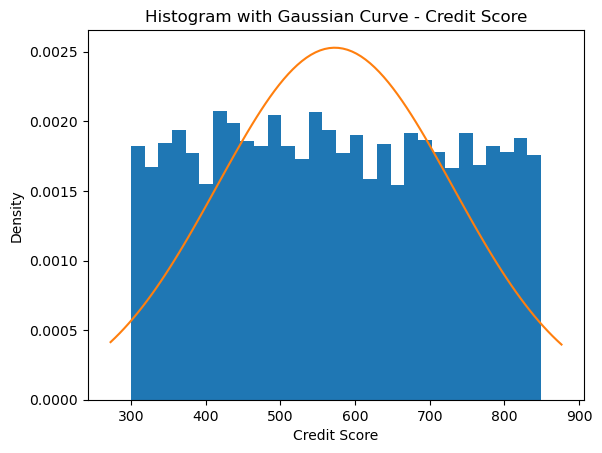

In [21]:
#Histogram with Gaussian Curve - Credit Score

data = df['Credit_Score']

# Plot histogram
plt.hist(data, bins=30, density=True)

# Gaussian curve
mean = np.mean(data)
std = np.std(data)

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mean, std)

plt.plot(x, p)

plt.title("Histogram with Gaussian Curve - Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Density")

plt.show()

In [23]:
#Skewness of Loan_Amount

skewness = df['Loan_Amount'].skew()
skewness

np.float64(0.036744709152578645)

In [25]:
#Kurtosis of Loan_Amount

kurtosis = df['Loan_Amount'].kurt()
kurtosis

np.float64(-1.1768284612013)

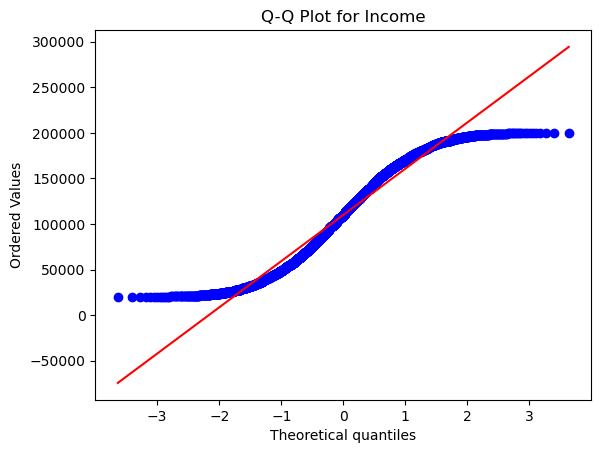

In [26]:
#Q-Q Plot for Income

stats.probplot(df['Income'], dist="norm", plot=plt)
plt.title("Q-Q Plot for Income")
plt.show()

## Linear Algebra Application

In [27]:
#Extract First 5 Customer Vectors
vectors = df[['Income', 'Loan_Amount']].head(5).values
vectors

array([[ 48054,  23066],
       [196469,  37746],
       [ 33233,   7460],
       [176140,  42297],
       [ 85727,  39743]])

In [29]:
#Dot Product Between Two Customers
v1 = vectors[0]
v2 = vectors[1]

dot_product = np.dot(v1, v2)
dot_product

np.int64(10311770562)

In [30]:
#Norm (L2 Norm) of a Customer Vector

norm_v1 = np.linalg.norm(v1)
norm_v1

np.float64(53303.163808539546)

In [31]:
#Angle Between Two Vectors

cos_theta = dot_product / (np.linalg.norm(v1) * np.linalg.norm(v2))

# angle in radians
angle_rad = np.arccos(cos_theta)

# convert to degrees
angle_deg = np.degrees(angle_rad)

angle_deg

np.float64(14.765821438938046)